In [11]:
import numpy
import matplotlib.pyplot as plt
import math
from scipy.signal import argrelextrema

In [12]:
F1E = [1]
FC = [1]
FE = [1]
steps = [0]
SGP1 = 0
SGP2 = 0
fS1 = 0
fS2 = 0
Zeros = []

max_x_FC = []
max_y_FC = []
max_x_FE = []
max_y_FE = []

min_x_FC = []
min_y_FC = []
min_x_FE = []
min_y_FE = []

In [13]:
N = 9
F = 460 * 10 ** 6

In [14]:
lambd = 299792458 / F
print("λ = " + str(lambd) + "(m)")
d = 0.25 * lambd
print("dcp = " + str(d) + "(m)")
k = (2 * numpy.pi) / lambd
print("k = " + str(k) + "(rad/m)")

λ = 0.6517227347826087(m)
dcp = 0.16293068369565217(m)
k = 9.640887100977736(rad/m)


In [15]:
for teta in numpy.arange(0.01, numpy.pi / 2, 0.00001):
    mn1 = abs((numpy.cos(numpy.pi/2 * numpy.sin(teta))/numpy.cos(teta)))
    mn2 = abs(numpy.sin((N * k * d * (1 - numpy.cos(teta)) / 2)) / (N * numpy.sin((k * d * (1 - numpy.cos(teta))) / 2)))
    mn3 = mn1 * mn2

    F1E += [mn1]
    FC += [mn2]
    FE += [mn3]

    if 0.707 < mn2 < 0.708:
        SGP1 = 2 * math.degrees(teta)
        fS1 = mn2

    if 0.707 < mn3 < 0.708:
        SGP2 = 2 * math.degrees(teta)
        fS2 = mn3

    steps += [math.degrees(teta)]


In [16]:
for i in range(1, len(FC) - 1):
    if FC[i] > FC[i - 1] and FC[i] > FC[i + 1]:
        max_x_FC.append(steps[i])
        max_y_FC.append(FC[i])
    if FE[i] > FE[i - 1] and FE[i] > FE[i + 1]:
        max_x_FE.append(steps[i])
        max_y_FE.append(FE[i])


for i in range(1, len(FC) - 1):
    if FC[i] < FC[i - 1] and FC[i] < FC[i + 1]:
        min_x_FC.append(steps[i])
        min_y_FC.append(FC[i])
    if FE[i] < FE[i - 1] and FE[i] < FE[i + 1]:
        min_x_FE.append(steps[i])
        min_y_FE.append(FC[i])


In [17]:
print("Ширина головної пелюстки в площині H = " + str(round(SGP1, 2)) + '\u00b0')
print("Ширина головної пелюстки в площині E = " + str(round(SGP2, 2)) + '\u00b0')


Ширина головної пелюстки в площині H = 73.35°
Ширина головної пелюстки в площині E = 59.51°


In [18]:

print("Табл. 1 - Значення нульових кутів")
print("-----------------")
print("| № |  θ  |FH(θ)|")
m = 1
for i in min_x_FC:
    print(f"| {m} |{i:.2f}|  {0}  |")
    m += 1
print("-----------------")
#
#
print("Табл. 2 - Значення максимальних кутів E")
print("-----------------")
print("| № |  θ  |FH(θ)|")
m = 1
for i in max_x_FE:
    print(f"| {m} |{i:.2f}| {max_y_FE[m-1]:.2f}|")
    m += 1
print("-----------------")

print("Табл. 3 - Значення максимальних кутів H")
print("-----------------")
print("| № |  θ  |FH(θ)|")
m = 1
for i in max_x_FC:
    print(f"| {m} |{i:.2f}| {max_y_FC[m-1]:.2f}|")
    m += 1
print("-----------------")

Табл. 1 - Значення нульових кутів
-----------------
| № |  θ  |FH(θ)|
| 1 |56.25|  0  |
| 2 |83.62|  0  |
-----------------
Табл. 2 - Значення максимальних кутів E
-----------------
| № |  θ  |FH(θ)|
| 1 |65.83| 0.07|
| 2 |86.66| 0.00|
-----------------
Табл. 3 - Значення максимальних кутів H
-----------------
| № |  θ  |FH(θ)|
| 1 |68.80| 0.23|
-----------------


In [19]:
# Код нижче виводить загальну таблицю. Якщо будете виводити окремо, то цю частину закоментуйте.
#len_value = [len(max_x_FC), len(max_x_FE), len(min_x_FC), len(min_x_FE)]
#print("Табл. 1 - Аналіз ДС Директорної антени в площині Н та Е")
#print("-----------------------------------------")
#print("| № |θminH|θminE|θmaxH|FH(θ)|θmaxE|FE(θ)|")
#for i in range(0, max(len_value)):
#    v1 = f" {i + 1:.0f}"
#    if len(v1) < len(str(max(len_value))) + 2:
#        v1 += " "
#    v2 = f"{min_x_FC[i]:.2f}" if i < len_value[3] else '  -  '
#    if len(v2) < 5:
#        v2 += "0"
#    v3 = f"{min_x_FE[i]:.2f}" if i < len_value[2] else '  -  '
#    if len(v3) < 5:
#        v3 += "0"
#    v4 = f"{max_x_FC[i]:.2f}" if i < len_value[0] else '  -  '
#    if len(v4) < 5:
#        v4 += "0"
#    h4 = f"{max_y_FC[i]:.3f}" if i < len_value[0] else '  -  '
#    if len(h4) < 5:
#        h4 += "0"
#    v5 = f"{max_x_FE[i]:.2f}" if i < len_value[1] else '  -  '
#    if len(v5) < 5:
#        v5 += "0"
#    h5 = f"{max_y_FE[i]:.3f}" if i < len_value[1] else '  -  '
#    if len(h5) < 5:
#        h5 += "0"
#    print(f"|{v1}|{v2}|{v3}|{v4}|{h4}|{v5}|{h5}|")
#print("-----------------------------------------")
# До сюди коментар, якщо не будете використовувати цей код для виводу таблиці.

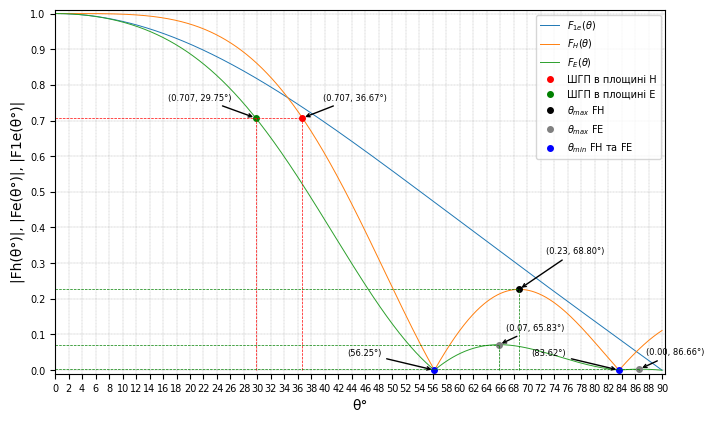

In [20]:
# Код нижче будує графік, який вам потрібен для звіту.
fig, ax = plt.subplots(figsize=(20/2.54, 12/2.54))
ax.plot(steps, F1E, linewidth=0.7, label="$ F_{1e}(θ) $")
ax.plot(steps, FC, linewidth=0.7, label="$ F_{H}(θ) $")
ax.plot(steps, FE, linewidth=0.7, label="$ F_{E}(θ) $")
ax.plot(SGP1/2, fS1, 'ro', markersize=4, label="ШГП в площині H")
ax.plot(SGP2/2, fS2, 'go', markersize=4, label="ШГП в площині E")

plt.annotate(f'({fS1:.3f}, {SGP1/2:.2f}\u00b0)',
                 xy=(SGP1 / 2, fS1),
                 xytext=((SGP1/2)+3, fS1+0.05),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.annotate(f'({fS2:.3f}, {SGP2/2:.2f}\u00b0)',
                 xy=(SGP2 / 2, fS2),
                 xytext=((SGP2/2)-13, fS2+0.05),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

ax.plot([0, SGP1/2], [fS2, fS2], 'r--', linewidth=0.5)
ax.plot([SGP2/2, SGP2/2], [0, fS2], 'r--', linewidth=0.5)
ax.plot([SGP1/2, SGP1/2], [0, fS1], 'r--', linewidth=0.5)

ax.plot(max_x_FC, max_y_FC, "o", markersize=4, color="black", label="$ \\theta_{max} $ FH")
ax.plot(max_x_FE, max_y_FE, "o", markersize=4, color="grey", label="$ \\theta_{max} $ FE")

ax.plot(min_x_FC, min_y_FC, "o", markersize=4, color="blue", label="$ \\theta_{min} $ FH та FE")
# ax.plot(min_x_FE, min_y_FE, "o", markersize=4, color="blue", label="$ \\theta_{min} $ FE")

ax.set_xlabel('θ' + '\u00b0', fontsize=10)
ax.set_ylabel('|Fh(θ' + '\u00b0' + ')|, |Fe(θ' + '\u00b0' + ')|, |F1e(θ' + '\u00b0' + ')|', fontsize=10)
plt.xticks(numpy.arange(0, 100, 2), fontsize=7)
plt.yticks(numpy.arange(0, 1.2, 0.1), fontsize=7)
plt.ylim(-0.01, 1.01)
plt.xlim(0, 90.5)


for i in range(len(max_x_FC)):
    plt.vlines(x=max_x_FC[i], ymin=0, ymax=max_y_FC[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FC[i], xmin=0, xmax=max_x_FC[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FC[i]:.2f}, {max_x_FC[i]:.2f}\u00b0)',
                 xy=(max_x_FC[i], max_y_FC[i]),
                 xytext=(max_x_FC[i]+4, max_y_FC[i]+0.1),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(max_x_FE)):
    plt.vlines(x=max_x_FE[i], ymin=0, ymax=max_y_FE[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.hlines(y=max_y_FE[i], xmin=0, xmax=max_x_FE[i], colors='green', linestyles='dashed', linewidth=0.5)
    plt.annotate(f'({max_y_FE[i]:.2f}, {max_x_FE[i]:.2f}\u00b0)',
                 xy=(max_x_FE[i], max_y_FE[i]),
                 xytext=(max_x_FE[i]+1, max_y_FE[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)
for i in range(len(min_x_FC)):
    plt.annotate(f'({min_x_FC[i]:.2f}\u00b0)',
                 xy=(min_x_FC[i], min_y_FC[i]),
                 xytext=(min_x_FC[i]-13, min_y_FC[i]+0.04),
                 arrowprops=dict(arrowstyle='->', color='black'), fontsize=6)

plt.legend(loc="upper right", fontsize=7)
plt.grid(which='both', linestyle='--', linewidth=0.2, color='gray')
# plt.show()
fig.savefig("ДС у площині Н та Е, лабораторна 1.jpg", dpi=600)
plt.show()
